In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier

In [2]:
file_path = (r"C:\Users\manis\data\New folder\data.xlsx")

customer_df = pd.read_excel(file_path, sheet_name="Customer_Info")
account_df = pd.read_excel(file_path, sheet_name="Account_Info")

# Clean column names
customer_df.columns = customer_df.columns.str.strip()
account_df.columns = account_df.columns.str.strip()

print("Customer:", customer_df.shape)
print("Account:", account_df.shape)

Customer: (10001, 8)
Account: (10002, 7)


In [4]:
df = pd.merge(customer_df, account_df, on="CustomerId")

print("Merged:", df.shape)
df.head()

Merged: (10004, 14)


,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure_x,EstimatedSalary,Balance,NumOfProducts,HasCrCard,Tenure_y,IsActiveMember,Exited
0,15634602,Hargrave,619,FRA,Female,42.0,2,€101348.88,0.00,1,Yes,2,Yes,1
1,15634602,Hargrave,619,FRA,Female,42.0,2,€101348.88,0.00,1,Yes,2,Yes,1
2,15647311,Hill,608,Spain,Female,41.0,1,€112542.58,83807.86,1,Yes,1,Yes,0
3,15619304,Onio,502,French,Female,42.0,8,€113931.57,159660.80,3,No,8,No,1
4,15701354,Boni,699,FRA,Female,39.0,1,€93826.63,0.00,2,No,1,No,0


In [5]:
df.columns = df.columns.str.strip().str.lower()

print(df.columns.tolist())

['customerid', 'surname', 'creditscore', 'geography', 'gender', 'age', 'tenure_x', 'estimatedsalary', 'balance', 'numofproducts', 'hascrcard', 'tenure_y', 'isactivemember', 'exited']


In [6]:
for col in df.columns:
    if df[col].dtype == "object":
        df[col] = (
            df[col]
            .astype(str)
            .str.replace("€", "", regex=False)
            .str.replace(",", "", regex=False)
            .str.strip()
        )

In [7]:
for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors="ignore")

C:\Users\manis\AppData\Local\Temp\ipykernel_38816\3514935324.py:2: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df[col] = pd.to_numeric(df[col], errors="ignore")


In [8]:
df["hascrcard"] = df["hascrcard"].map({"Yes": 1, "No": 0})
df["isactivemember"] = df["isactivemember"].map({"Yes": 1, "No": 0})

In [9]:
categorical_cols = ["geography", "gender"]

le = LabelEncoder()

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

In [10]:
df = df.drop(columns=["surname", "customerid"], errors="ignore")

In [11]:
print("Missing values:\n", df.isnull().sum())

df = df.dropna()

Missing values:
 creditscore        0
geography          0
gender             0
age                3
tenure_x           0
estimatedsalary    0
balance            0
numofproducts      0
hascrcard          0
tenure_y           0
isactivemember     0
exited             0
dtype: int64


In [12]:
print("\nData Types:\n", df.dtypes)

# Check if any object columns remain
for col in df.columns:
    if df[col].dtype == "object":
        print("❌ Still object column:", col)


Data Types:
 creditscore          int64
geography            int64
gender               int64
age                float64
tenure_x             int64
estimatedsalary    float64
balance            float64
numofproducts        int64
hascrcard            int64
tenure_y             int64
isactivemember       int64
exited               int64
dtype: object


In [13]:
X = df.drop("exited", axis=1)
y = df["exited"]

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [15]:
model = RandomForestClassifier(n_estimators=200, random_state=42)

model.fit(X_train, y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [16]:
y_pred = model.predict(X_test)

In [17]:
print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.8675662168915542

Classification Report:

              precision    recall  f1-score   support

           0       0.88      0.97      0.92      1599
           1       0.79      0.47      0.59       402

    accuracy                           0.87      2001
   macro avg       0.83      0.72      0.75      2001
weighted avg       0.86      0.87      0.85      2001


Confusion Matrix:

[[1548   51]
 [ 214  188]]


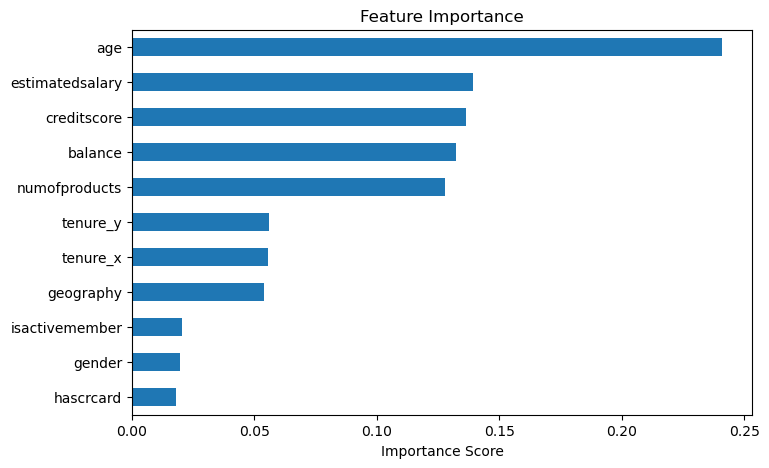

In [18]:
importance = pd.Series(model.feature_importances_, index=X.columns)
importance = importance.sort_values()

plt.figure(figsize=(8,5))
importance.plot(kind="barh")

plt.title("Feature Importance")
plt.xlabel("Importance Score")
plt.show()

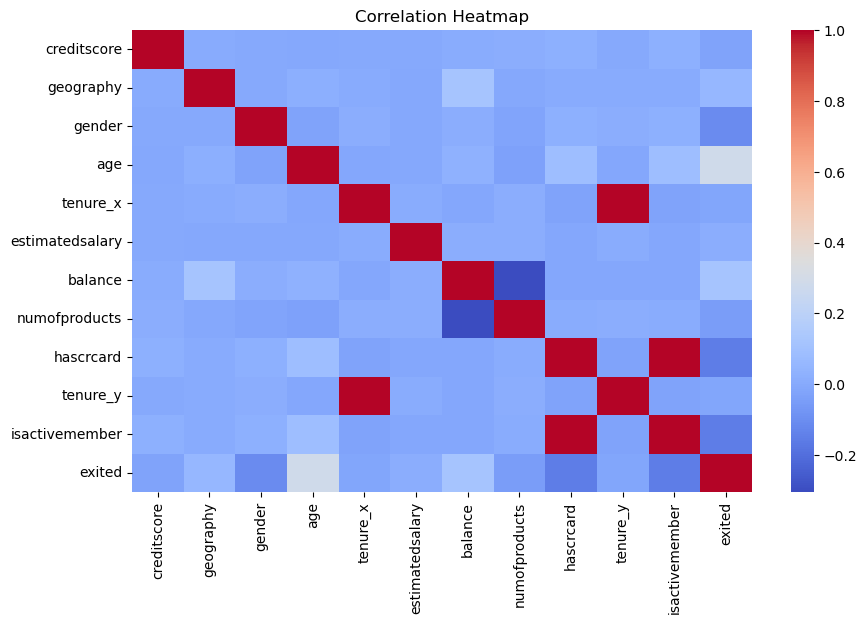

In [19]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), cmap="coolwarm")

plt.title("Correlation Heatmap")
plt.show()